<div style="text-align:left;">
  <a href="https://code213.tech/" target="_blank">
    <img src="./images/code213.PNG" alt="Code213 Logo" width="200"/>
  </a>
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b>Predicting Breast Cancer Classification Using Logistic Regression</b></font></center>

<div style="text-align:center;">
    <img src="./plotly_app_breaset_cancer/assets/celltumor.PNG" width="400"/>
</div>

***

**Author**: Latreche Sara  
**Date**: /2025  

### Table of Contents
- [1 | Project Overview and Objectives](#env)
- [1.1 | Setting Up the Environment](#setup)
- [1.2 | Exploring the Dataset](#explore)
- [1.3 | Preprocessing the Dataset](#prep)
- [1.4 | Select and Train the Model](#train)
- [1.5 | Evaluating the Model](#eval)
- [1.6 | Fine-Tune Your Model](#tune)
- [1.7 | Conclusion](#concl)

---

## <b>1 <span style='color:#e61227'>|</span> <a id='intro'>Project Overview and Objectives</a></b>

In this case study, students will learn how to:  
1. Load and explore the breast cancer dataset.  
2. Remove multicollinearity using Variance Inflation Factor (VIF).  
3. Split the dataset with stratification to maintain class distribution.  
4. Train logistic regression models with scaling and cross-validation.  
5. Evaluate model performance using accuracy, F1-score, ROC-AUC, and confusion matrix.  
6. Compare full vs reduced feature models.  
7. Visualize coefficients and ROC curves for interpretability.  

This notebook is designed for step-by-step learning. Each section contains **explanations, code, and visualizations**, so students can understand **why each step is important**.


## <b>1 <span style='color:#e61227'>|</span> <a id='env'>Project Overview and Objectives</a></b>

### Project Overview

Breast cancer is one of the most common and life-threatening cancers affecting women worldwide. Early detection is crucial, as timely diagnosis and treatment dramatically improve patient outcomes. In this project, you will take on the role of a **research data scientist**, leveraging **machine learning** to assist in the early identification of malignant tumors using the **Breast Cancer Wisconsin (Diagnostic) dataset**, a widely cited dataset in medical data science research. You can access the original dataset and paper here: [UCI Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29).

As a medical data scientist, you are tasked with building a predictive model that can accurately distinguish between **malignant** and **benign** tumors based on features derived from digitized images of fine needle aspirates (FNA) of breast masses. These features describe characteristics such as tumor radius, texture, smoothness, compactness, and concavity, all of which are clinically relevant. By framing this as a **binary classification problem**, you aim to provide a reliable, interpretable model that can support clinicians in making informed decisions, reduce unnecessary biopsies, and ultimately improve patient care.

Through this case study, you will learn how to systematically approach a **real-world medical machine learning problem**: exploring and preprocessing data, removing multicollinearity using Variance Inflation Factor (VIF), splitting the dataset with stratification, training logistic regression models with scaling and cross-validation, evaluating performance with accuracy, F1-score, ROC-AUC, and confusion matrices, and interpreting model coefficients. The overarching goal is not only to achieve high predictive performance but also to generate **actionable insights** that could guide clinical decision-making.


## <b>1.1 <span style='color:#e61227'>|</span> <a id='setup'>Setting Up the Environment</a></b>


In [1]:
# ============================================================
#  Environment Setup for Jupyter Notebook
# ============================================================

# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# Display settings
# ----------------------------
# To plot inline in Jupyter
%matplotlib inline

# Matplotlib global settings for nicer figures
import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
mpl.rc('figure', figsize=(8, 5))  # default figure size

# ----------------------------
# Project directories
# ----------------------------
PROJECT_ROOT_DIR = "."             # your project root
PROJECT_ROOT_DIR_ID = "end_to_end_project"  # custom subfolder name
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", PROJECT_ROOT_DIR_ID)

# Make sure the directory exists
os.makedirs(IMAGES_PATH, exist_ok=True)

# ----------------------------
# Save figure function
# ----------------------------
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """
    Save matplotlib figure to images folder
    """
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print(f"Saving figure {fig_id} to {path}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# ----------------------------
# Optional: Pandas display options
# ----------------------------
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)


## <b>1.2 <span style='color:#e61227'>|</span> <a id='explore'>Exploring the Dataset</a></b>


Dataset shape: (569, 30)

Target distribution:
target
1    357
0    212
Name: count, dtype: int64


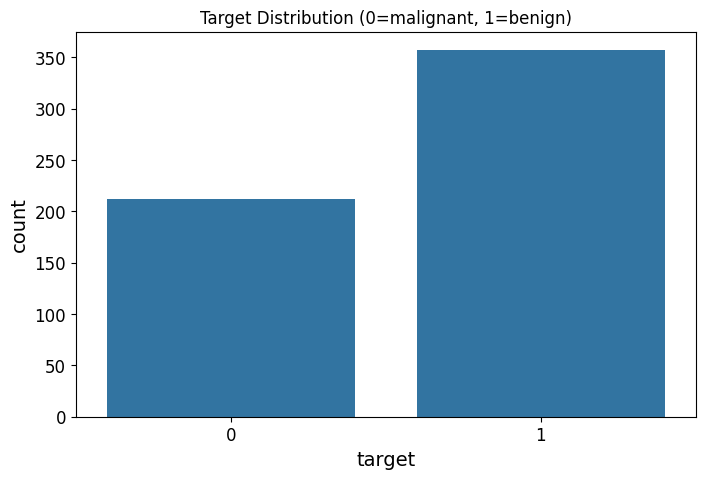

In [3]:
# Load dataset
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_full = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Basic info
print("Dataset shape:", X_full.shape)
print("\nTarget distribution:")
print(y.value_counts())

# Optional: quick target visualization
sns.countplot(x=y)
plt.title("Target Distribution (0=malignant, 1=benign)")
plt.show()

## <b>1.3 <span style='color:#e61227'>|</span> <a id='prep'>Preprocessing the Dataset</a></b>


In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(df):
    """Calculate VIF for all features in a DataFrame"""
    return pd.DataFrame({
        "feature": df.columns,
        "VIF": [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    })

# Make a copy to reduce
X_reduced = X_full.copy()

# Iteratively drop features with VIF > 10
while True:
    vif = calculate_vif(X_reduced)
    max_vif = vif["VIF"].max()
    if max_vif > 10:
        drop_feature = vif.sort_values("VIF", ascending=False).iloc[0]["feature"]
        print(f"Dropping {drop_feature} with VIF={max_vif:.2f}")
        X_reduced = X_reduced.drop(columns=[drop_feature])
    else:
        break

print("\nRemaining features after VIF reduction:")
print(list(X_reduced.columns))
print("Reduced dataset shape:", X_reduced.shape)



Dropping mean radius with VIF=63306.17
Dropping worst radius with VIF=7573.94
Dropping mean perimeter with VIF=3901.90
Dropping worst perimeter with VIF=668.39
Dropping mean fractal dimension with VIF=508.09
Dropping worst smoothness with VIF=368.05
Dropping worst texture with VIF=309.54
Dropping worst fractal dimension with VIF=184.68
Dropping worst symmetry with VIF=167.31
Dropping mean concavity with VIF=142.30
Dropping radius error with VIF=104.99
Dropping worst concave points with VIF=100.95
Dropping mean smoothness with VIF=87.00
Dropping mean compactness with VIF=74.72
Dropping mean area with VIF=67.47
Dropping worst compactness with VIF=49.02
Dropping perimeter error with VIF=43.73
Dropping mean symmetry with VIF=36.08
Dropping mean texture with VIF=23.71
Dropping concave points error with VIF=18.16
Dropping compactness error with VIF=15.73
Dropping worst area with VIF=13.98
Dropping mean concave points with VIF=11.18

Remaining features after VIF reduction:
['texture error', '

In [5]:
# ============================================================
# 2) Stratified train/test split
# ============================================================

from sklearn.model_selection import train_test_split

# Full dataset
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Reduced dataset
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain/test shapes (reduced features):", Xr_train.shape, Xr_test.shape)


Train/test shapes (reduced features): (455, 7) (114, 7)


In [6]:
# ============================================================
# 3) Feature Scaling with RobustScaler
# ============================================================

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# Fit on training data and transform both train/test
Xr_train_scaled = scaler.fit_transform(Xr_train)
Xr_test_scaled = scaler.transform(Xr_test)

Xf_train_scaled = scaler.fit_transform(Xf_train)
Xf_test_scaled = scaler.transform(Xf_test)

print("\nScaling complete. Sample of scaled features (reduced):")
pd.DataFrame(Xr_train_scaled, columns=X_reduced.columns).head()


Scaling complete. Sample of scaled features (reduced):


,texture error,area error,smoothness error,concavity error,symmetry error,fractal dimension error,worst concavity
0,-0.171,-0.417,0.239,-0.560,-0.366,-0.220,-0.670
1,-0.118,1.044,0.907,1.050,0.686,0.385,1.085
2,1.322,-0.084,0.782,-0.920,1.647,-0.913,-0.828
3,-0.902,-0.119,-0.173,-0.016,-0.033,-0.085,0.101
4,1.398,-0.250,0.056,-0.431,1.825,-0.080,-0.557


## <b>1.4 <span style='color:#e61227'>|</span> <a id='train'>Select and Train the Model</a></b>


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# ----------------------------
# 1) Define pipeline
# ----------------------------
pipe = Pipeline([
    ("scaler", RobustScaler()),      # Robust scaling handles outliers
    ("clf", LogisticRegression(max_iter=5000))
])

# Hyperparameter grid for tuning
param_grid = {
    "clf__C": [0.01, 0.1, 1, 5, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"]
}

# Stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ----------------------------
# 2) Train model on reduced features
# ----------------------------
grid_reduced = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_reduced.fit(Xr_train, yr_train)
print("Best parameters (Reduced):", grid_reduced.best_params_)

# ----------------------------
# 3) Train model on full features
# ----------------------------
grid_full = GridSearchCV(pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_full.fit(Xf_train, yf_train)
print("Best parameters (Full):", grid_full.best_params_)

Best parameters (Reduced): {'clf__C': 5, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best parameters (Full): {'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}


## <b>1.5 <span style='color:#e61227'>|</span> <a id='eval'>Evaluating the Model</a></b>



--- Reduced (VIF-selected features) ---
Accuracy: 0.956140350877193
F1-score: 0.9645390070921985
ROC-AUC: 0.9894179894179894
Classification report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



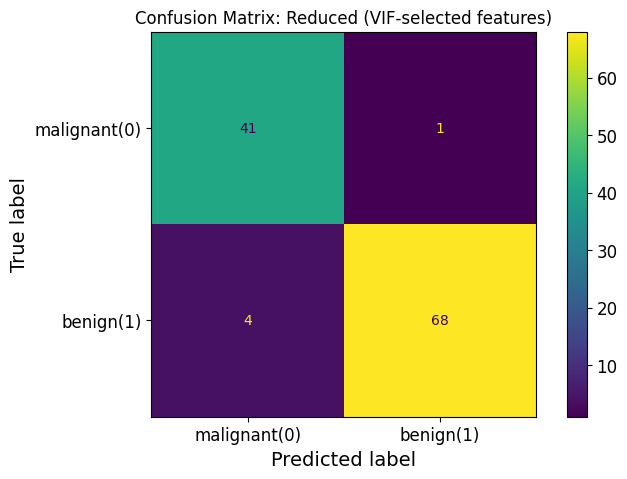


--- Full (all features) ---
Accuracy: 0.9736842105263158
F1-score: 0.9793103448275862
ROC-AUC: 0.996031746031746
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



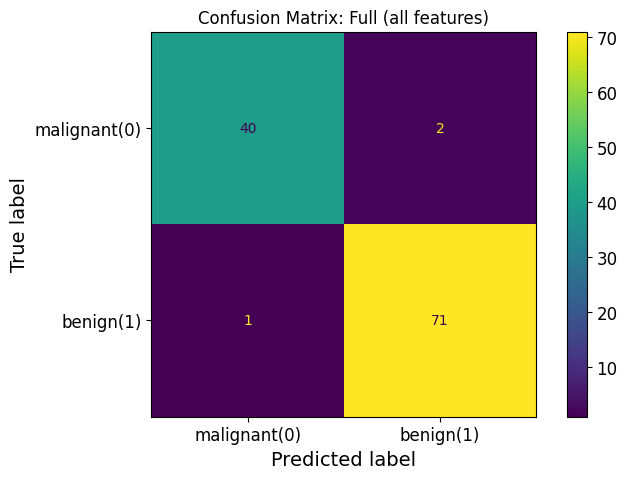

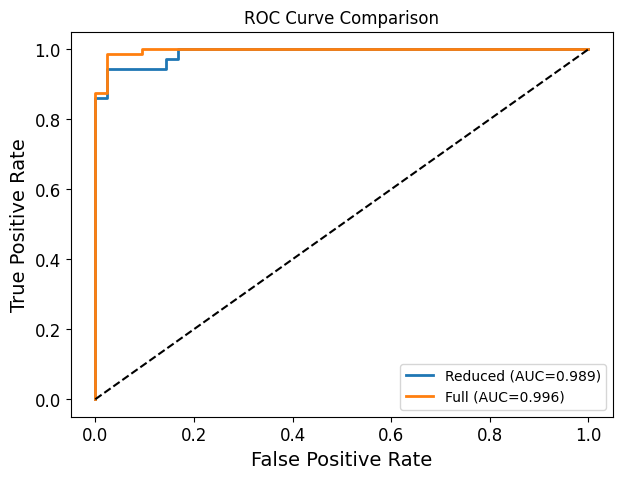

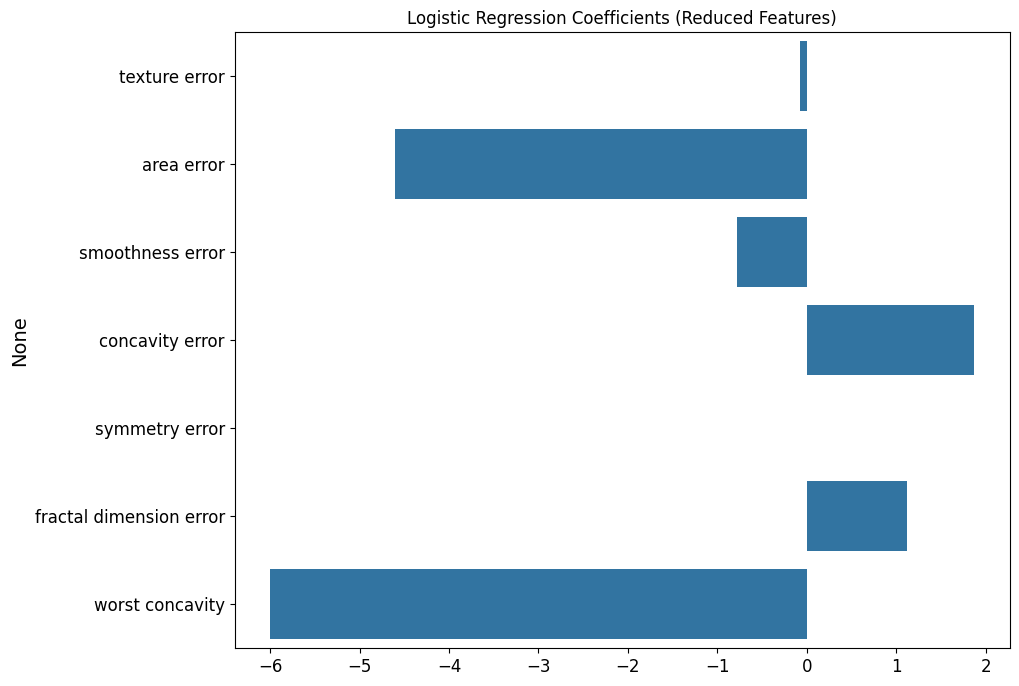

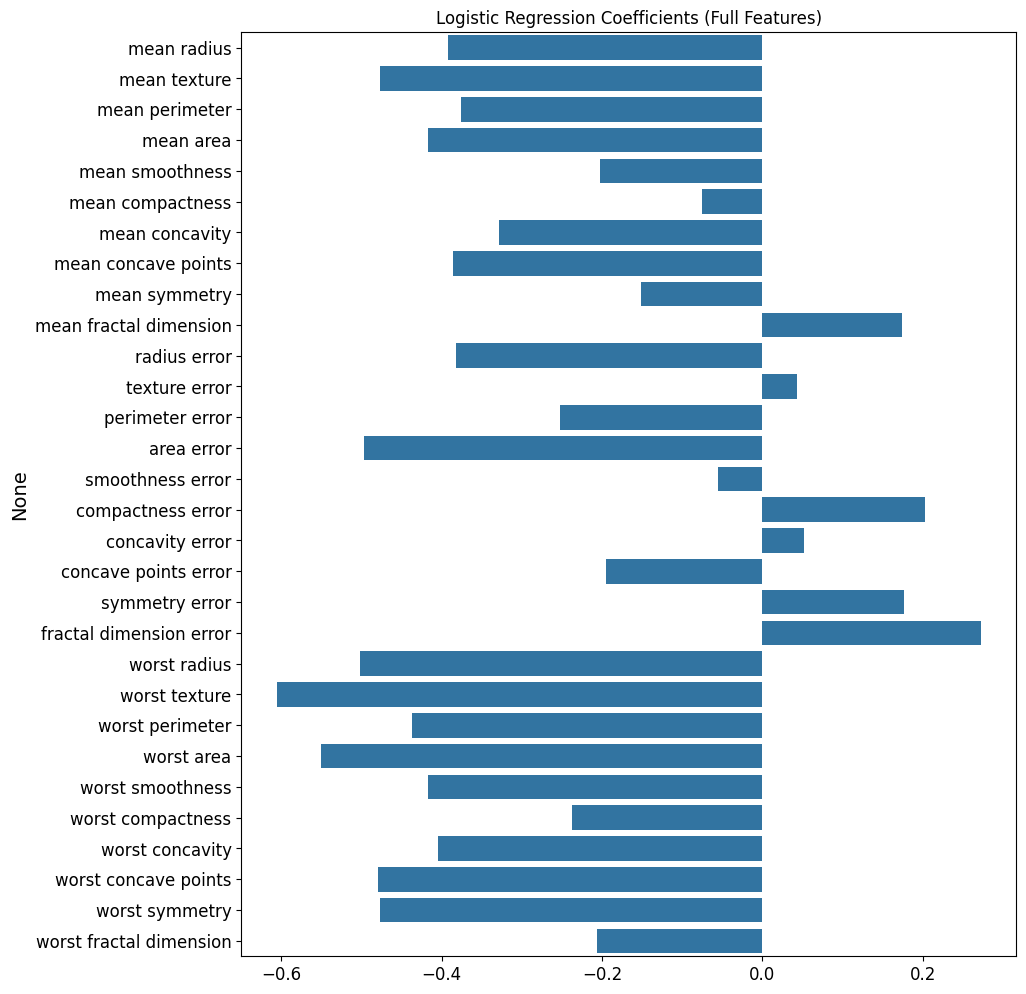

In [8]:

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------------------
# 1) Evaluation function
# ----------------------------
def evaluate_model(grid, X_test, y_test, label):
    """Evaluate a trained GridSearchCV model"""
    model = grid.best_estimator_
    clf = model.named_steps["clf"]

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    print(f"\n--- {label} ---")
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print("ROC-AUC:", roc)
    print("Classification report:\n", classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant(0)', 'benign(1)'])
    disp.plot()
    plt.title(f"Confusion Matrix: {label}")
    plt.show()

    # ROC data
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    return fpr, tpr, roc, clf.coef_.ravel()


# ----------------------------
# 2) Evaluate Reduced vs Full
# ----------------------------
fpr_r, tpr_r, roc_r, coef_r = evaluate_model(grid_reduced, Xr_test, yr_test, "Reduced (VIF-selected features)")
fpr_f, tpr_f, roc_f, coef_f = evaluate_model(grid_full, Xf_test, yf_test, "Full (all features)")


# ----------------------------
# 3) ROC Curve Comparison
# ----------------------------
plt.figure(figsize=(7, 5))
plt.plot(fpr_r, tpr_r, label=f"Reduced (AUC={roc_r:.3f})", linewidth=2)
plt.plot(fpr_f, tpr_f, label=f"Full (AUC={roc_f:.3f})", linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# ----------------------------
# 4) Coefficient Comparison
# ----------------------------
coef_full = pd.Series(coef_f, index=X_full.columns)
coef_reduced = pd.Series(coef_r, index=X_reduced.columns)

plt.figure(figsize=(10, 8))
sns.barplot(x=coef_reduced.values, y=coef_reduced.index)
plt.title("Logistic Regression Coefficients (Reduced Features)")
plt.show()

plt.figure(figsize=(10, 12))
sns.barplot(x=coef_full.values, y=coef_full.index)
plt.title("Logistic Regression Coefficients (Full Features)")
plt.show()


## <b>1.6 <span style='color:#e61227'>|</span> <a id='tune'>Fine-Tune Your Model</a></b>


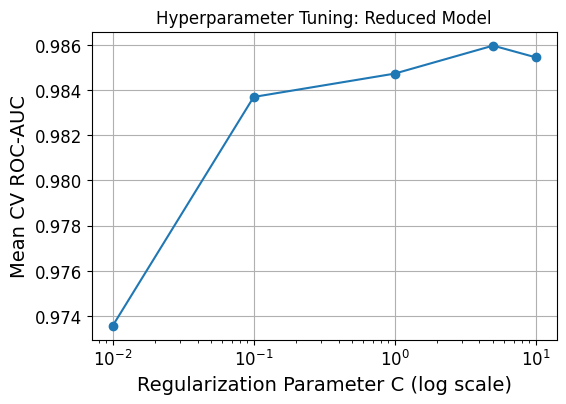

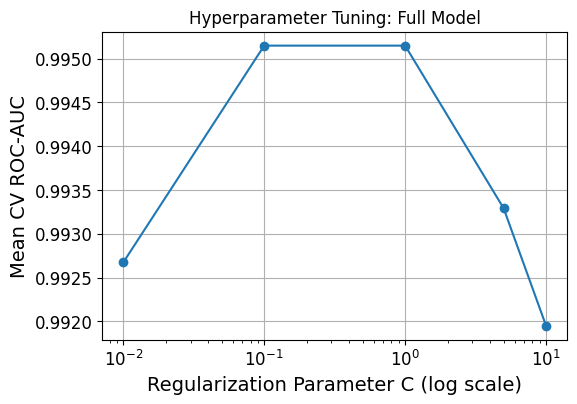

Best Reduced Model: C = 5 ROC-AUC = 0.9859649122807017
Best Full Model: C = 0.1 ROC-AUC = 0.9951496388028895


In [9]:

import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# 1) Collect GridSearchCV results for Reduced Model
# ----------------------------
results_reduced = pd.DataFrame(grid_reduced.cv_results_)
C_values = results_reduced["param_clf__C"].astype(float)
mean_auc = results_reduced["mean_test_score"]

plt.figure(figsize=(6, 4))
plt.plot(C_values, mean_auc, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel("Regularization Parameter C (log scale)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("Hyperparameter Tuning: Reduced Model")
plt.grid(True)
plt.show()

# ----------------------------
# 2) Collect GridSearchCV results for Full Model
# ----------------------------
results_full = pd.DataFrame(grid_full.cv_results_)
C_values_full = results_full["param_clf__C"].astype(float)
mean_auc_full = results_full["mean_test_score"]

plt.figure(figsize=(6, 4))
plt.plot(C_values_full, mean_auc_full, marker='o', linestyle='-')
plt.xscale('log')
plt.xlabel("Regularization Parameter C (log scale)")
plt.ylabel("Mean CV ROC-AUC")
plt.title("Hyperparameter Tuning: Full Model")
plt.grid(True)
plt.show()

# ----------------------------
# 3) Optional: Best model info
# ----------------------------
print("Best Reduced Model: C =", grid_reduced.best_params_["clf__C"],
      "ROC-AUC =", grid_reduced.best_score_)
print("Best Full Model: C =", grid_full.best_params_["clf__C"],
      "ROC-AUC =", grid_full.best_score_)


In [10]:
## Testing the models on Test Data

# ----------------------------
# 1) Reduced Model
# ----------------------------
best_reduced = grid_reduced.best_estimator_
y_pred_r = best_reduced.predict(Xr_test)
y_proba_r = best_reduced.predict_proba(Xr_test)[:, 1]

print("=== Reduced Model ===")
print("Accuracy:", accuracy_score(yr_test, y_pred_r))
print("F1-score:", f1_score(yr_test, y_pred_r))
print("ROC-AUC:", roc_auc_score(yr_test, y_proba_r))
print("Classification Report:\n", classification_report(yr_test, y_pred_r))

# ----------------------------
# 2) Full Model
# ----------------------------
best_full = grid_full.best_estimator_
y_pred_f = best_full.predict(Xf_test)
y_proba_f = best_full.predict_proba(Xf_test)[:, 1]

print("\n=== Full Model ===")
print("Accuracy:", accuracy_score(yf_test, y_pred_f))
print("F1-score:", f1_score(yf_test, y_pred_f))
print("ROC-AUC:", roc_auc_score(yf_test, y_proba_f))
print("Classification Report:\n", classification_report(yf_test, y_pred_f))


=== Reduced Model ===
Accuracy: 0.956140350877193
F1-score: 0.9645390070921985
ROC-AUC: 0.9894179894179894
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


=== Full Model ===
Accuracy: 0.9736842105263158
F1-score: 0.9793103448275862
ROC-AUC: 0.996031746031746
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        42
           1       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## <b>1.7 <span style='color:#e61227'>|</span> <a id='concl'>Conclusion</a></b>


In [12]:
## Saving and Loading the Model for Deployment

import joblib
import os

# ----------------------------
# 1) Choose the model to save (let’s pick the reduced model)
# ----------------------------
best_model = grid_reduced.best_estimator_

# ----------------------------
# 2) Define folder and filename
# ----------------------------
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, "logreg_breastcancer_reduced.pkl")

# ----------------------------
# 3) Save the model
# ----------------------------
joblib.dump(best_model, model_path)
print(f"Model saved at: {model_path}")

# ----------------------------
# 4) Load the model
# ----------------------------
loaded_model = joblib.load(model_path)
print("Model loaded successfully!")

# ----------------------------
# 5) Make predictions using the loaded model
# ----------------------------
y_pred_loaded = loaded_model.predict(Xr_test)
y_proba_loaded = loaded_model.predict_proba(Xr_test)[:, 1]

print("Test Accuracy:", accuracy_score(yr_test, y_pred_loaded))
print("Test ROC-AUC:", roc_auc_score(yr_test, y_proba_loaded))


Model saved at: saved_models\logreg_breastcancer_reduced.pkl
Model loaded successfully!
Test Accuracy: 0.956140350877193
Test ROC-AUC: 0.9894179894179894


In [13]:
# ============================================================
# Saving Reduced Logistic Regression Model and Training Data
# ============================================================

import os
import joblib
import pandas as pd

# Paths
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, "logreg_breastcancer_reduced.pkl")
TRAIN_PATH = os.path.join(MODEL_DIR, "X_train_y_train.csv")

# ------------------------------------------------------------
# 1) Save the model
# ------------------------------------------------------------
# Assuming `best_model` is your reduced pipeline (scaler + logistic regression)
joblib.dump(best_model, MODEL_PATH)
print(f"Model saved at: {MODEL_PATH}")

# ------------------------------------------------------------
# 2) Save training data (needed for performance plots in Dash)
# ------------------------------------------------------------
X_train_y_train = Xr_train.copy()
X_train_y_train["target"] = yr_train.values
X_train_y_train.to_csv(TRAIN_PATH, index=False)
print(f"Training data saved at: {TRAIN_PATH}")

# ------------------------------------------------------------
# 3) Load the model and training data (for Dash)
# ------------------------------------------------------------
loaded_model = joblib.load(MODEL_PATH)
train_data = pd.read_csv(TRAIN_PATH)

print("Model and training data loaded successfully!")
print("Model features:", list(Xr_train.columns))
print("Training data shape:", train_data.shape)

# ------------------------------------------------------------
# 4) Quick test to check predictions
# ------------------------------------------------------------
y_pred_loaded = loaded_model.predict(Xr_test)
y_proba_loaded = loaded_model.predict_proba(Xr_test)[:, 1]

from sklearn.metrics import accuracy_score, roc_auc_score
print("Test Accuracy:", accuracy_score(yr_test, y_pred_loaded))
print("Test ROC-AUC:", roc_auc_score(yr_test, y_proba_loaded))


Model saved at: saved_models\logreg_breastcancer_reduced.pkl
Training data saved at: saved_models\X_train_y_train.csv
Model and training data loaded successfully!
Model features: ['texture error', 'area error', 'smoothness error', 'concavity error', 'symmetry error', 'fractal dimension error', 'worst concavity']
Training data shape: (455, 8)
Test Accuracy: 0.956140350877193
Test ROC-AUC: 0.9894179894179894


Congratulations! 
On building your model and saving it!